In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('amazon.csv')

In [3]:
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [4]:
df.drop(columns=['img_link','product_link','review_content'], inplace=True)
df.columns

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title'],
      dtype='object')

In [5]:
df.dtypes

product_id             object
product_name           object
category               object
discounted_price       object
actual_price           object
discount_percentage    object
rating                 object
rating_count           object
about_product          object
user_id                object
user_name              object
review_id              object
review_title           object
dtype: object

### Data Cleaning

In [6]:
df['discounted_price'] = df['discounted_price'].replace('[₹,]','',regex=True).astype(float)
df['discounted_price'].head()

0    399.0
1    199.0
2    199.0
3    329.0
4    154.0
Name: discounted_price, dtype: float64

In [7]:
df['actual_price'] = df['actual_price'].replace('[₹,]','',regex=True).astype(float)

In [8]:
df['discount_percentage'] = df['discount_percentage'].replace("%","",regex=True).astype(float)

In [9]:
# Clean 'rating' and convert to numeric (errors='coerce' turns anomalies like '|' into NaN)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# Clean 'rating_count' by removing commas and converting to numeric
df['rating_count'] = df['rating_count'].str.replace(',', '', regex=False)
df['rating_count'] = pd.to_numeric(df['rating_count'], errors='coerce')

# Drop any new missing values that might have been introduced by coercion
df.dropna(inplace=True)

print(df[['rating', 'rating_count']].dtypes)

rating          float64
rating_count    float64
dtype: object


### Missing Value

In [10]:
df.dropna(inplace=True)

In [11]:
df.shape

(1462, 13)

### Univariable Analysis

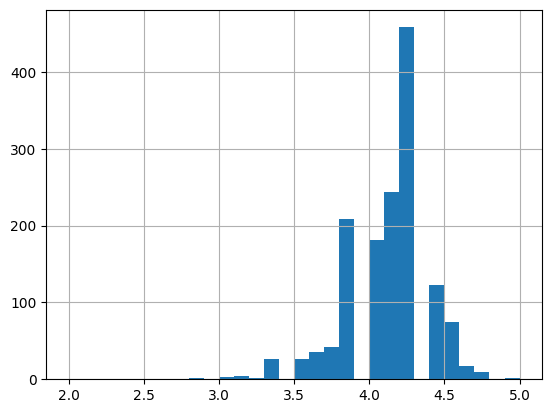

In [12]:
df['rating'].hist(bins=30)
plt.show()

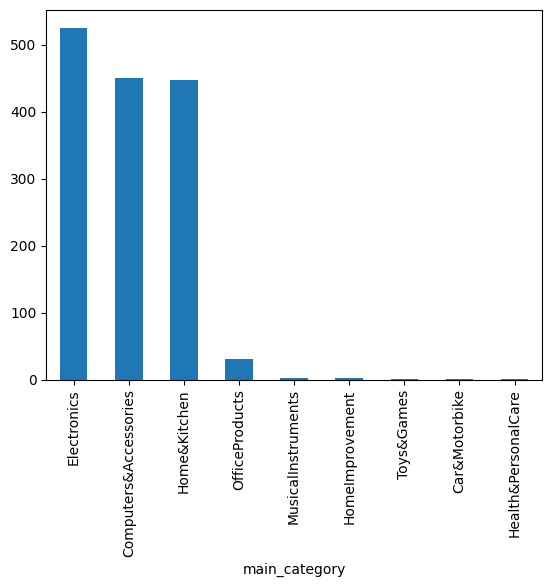

In [13]:
df['main_category'] = df['category'].str.split("|").str[0]
df['main_category'].value_counts().plot(kind='bar')
plt.show()

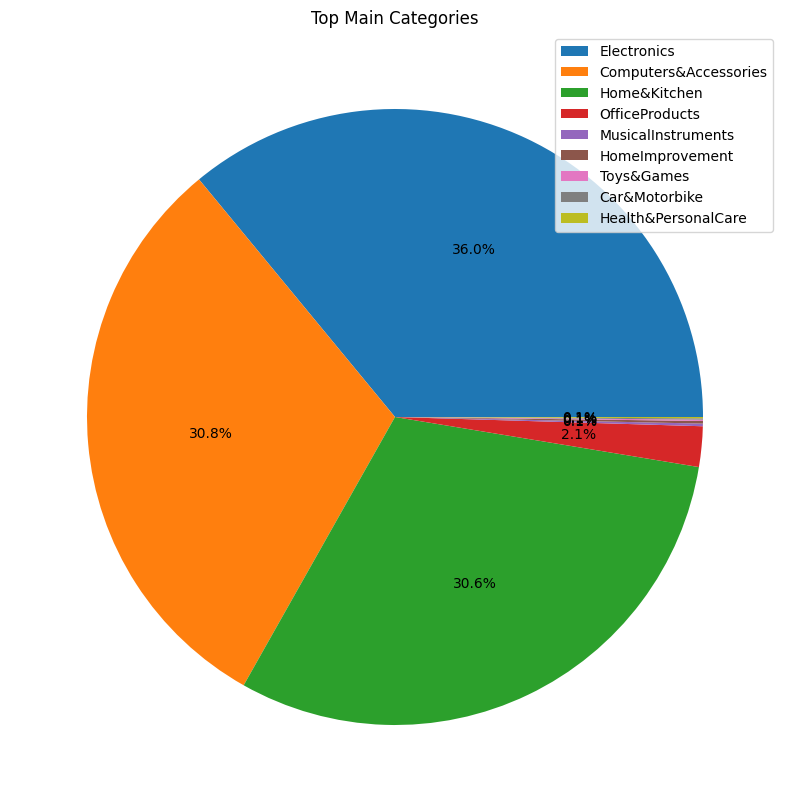

In [14]:
category_counts = df['main_category'].value_counts().head(10)

plt.figure(figsize=(10,10))

plt.pie(
    category_counts,
    labels=None,
    autopct='%1.1f%%'
)

plt.legend(category_counts.index, loc='best')
plt.title('Top Main Categories')

plt.show()

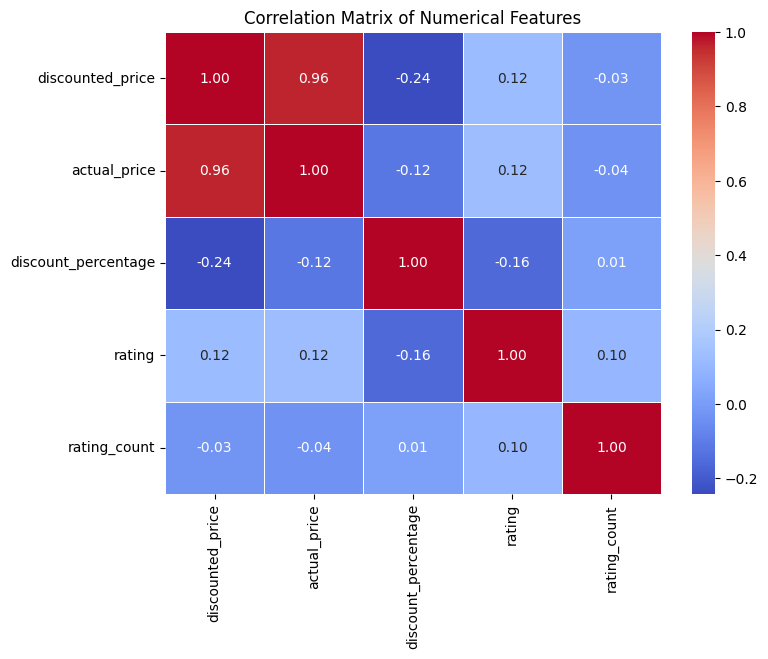

In [15]:
# Plotting a Correlation Heatmap
plt.figure(figsize=(8, 6))
numeric_cols = ['discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count']

# Calculate correlation matrix
corr_matrix = df[numeric_cols].corr()

# Draw heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

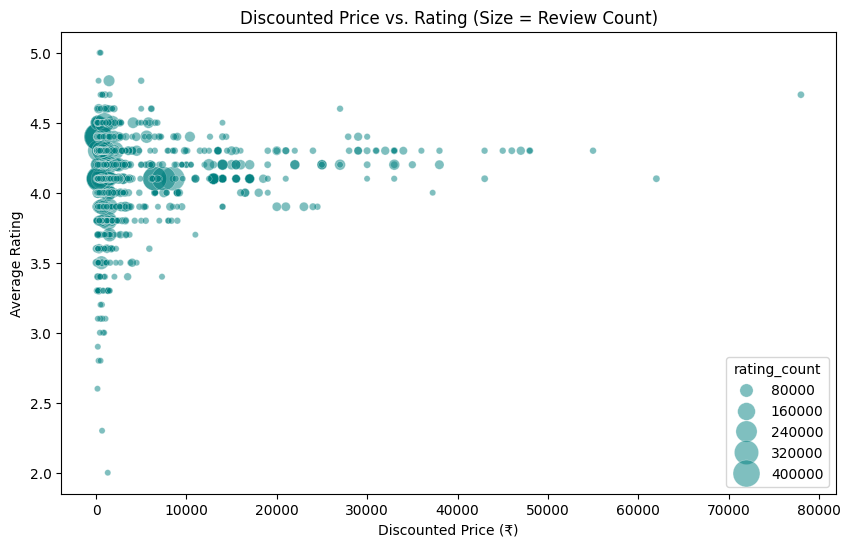

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='discounted_price', 
    y='rating', 
    size='rating_count', 
    sizes=(20, 400), 
    alpha=0.5, 
    color='teal'
)
plt.title('Discounted Price vs. Rating (Size = Review Count)')
plt.xlabel('Discounted Price (₹)')
plt.ylabel('Average Rating')
plt.show()

C:\Users\PRINCE\AppData\Local\Temp\ipykernel_4320\3076184385.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='main_category', y='rating', data=df_top5, palette='Set2')


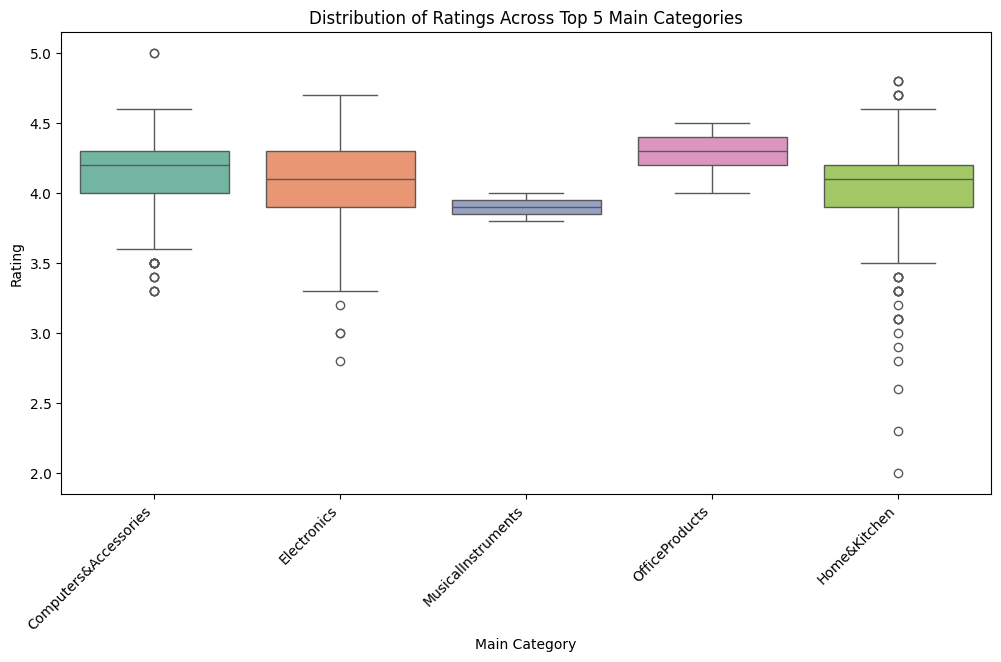

In [17]:
# Get the top 5 main categories
top_5_categories = df['main_category'].value_counts().nlargest(5).index

# Filter dataframe
df_top5 = df[df['main_category'].isin(top_5_categories)]

# Create a boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x='main_category', y='rating', data=df_top5, palette='Set2')
plt.xticks(rotation=45, ha='right')
plt.title('Distribution of Ratings Across Top 5 Main Categories')
plt.ylabel('Rating')
plt.xlabel('Main Category')
plt.show()

In [18]:
# Find products with a rating >= 4.5 and more than 50,000 reviews
top_products = df[(df['rating'] >= 4.5) & (df['rating_count'] > 50000)]

# Sort them by highest review count
top_products = top_products.sort_values(by='rating_count', ascending=False)

print(f"Found {len(top_products)} highly credible top-rated products.")
top_products[['product_name', 'main_category', 'rating', 'rating_count', 'discounted_price']].head(10)

Found 11 highly credible top-rated products.


,product_name,main_category,rating,rating_count,discounted_price
864,SanDisk Extreme SD UHS I 64GB Card for 4K Vide...,Electronics,4.5,205052.0,939.0
40,AmazonBasics USB 2.0 Cable - A-Male to B-Male ...,Computers&Accessories,4.5,107687.0,209.0
852,AmazonBasics USB 2.0 Cable - A-Male to B-Male ...,Computers&Accessories,4.5,107686.0,209.0
810,Crucial BX500 240GB 3D NAND SATA 6.35 cm (2.5-...,Computers&Accessories,4.5,92925.0,1815.0
212,AmazonBasics USB 2.0 Extension Cable for Perso...,Computers&Accessories,4.5,74977.0,299.0
30,AmazonBasics USB 2.0 - A-Male to A-Female Exte...,Computers&Accessories,4.5,74976.0,199.0
802,AmazonBasics USB 2.0 - A-Male to A-Female Exte...,Computers&Accessories,4.5,74976.0,199.0
734,"Logitech M235 Wireless Mouse, 1000 DPI Optical...",Computers&Accessories,4.5,54405.0,699.0
1145,Swiffer Instant Electric Water Heater Faucet T...,Home&Kitchen,4.8,53803.0,1439.0
625,Seagate Expansion 1TB External HDD - USB 3.0 f...,Computers&Accessories,4.5,50810.0,4098.0
